In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
from omegaconf import OmegaConf
data_info = OmegaConf.load(f"../data_classification.yaml")

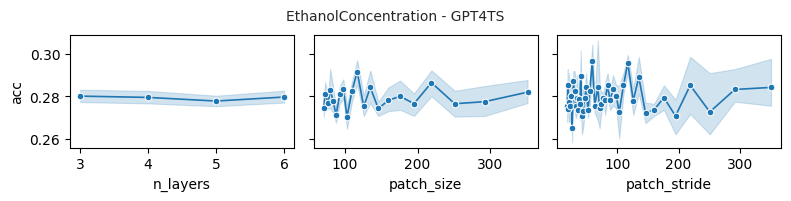

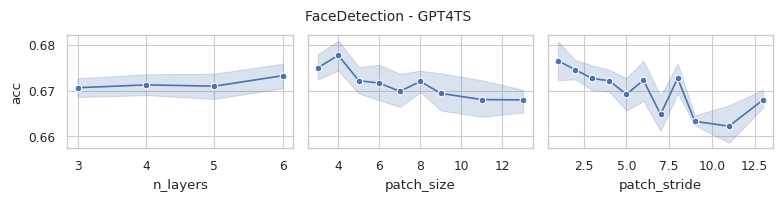

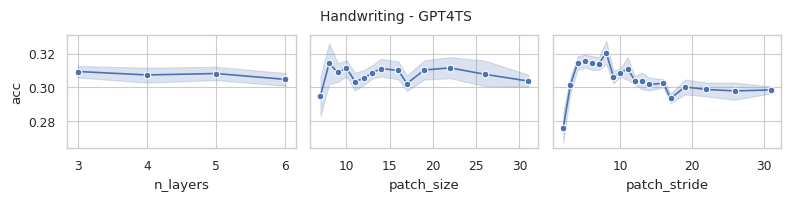

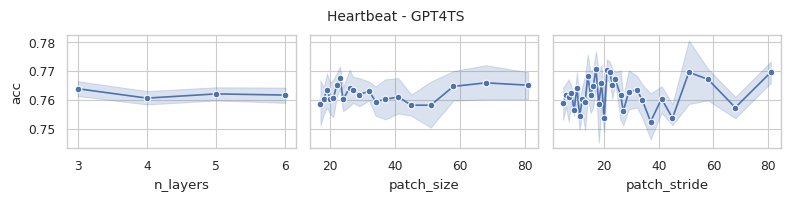

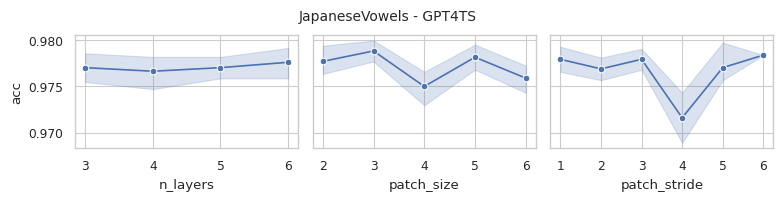

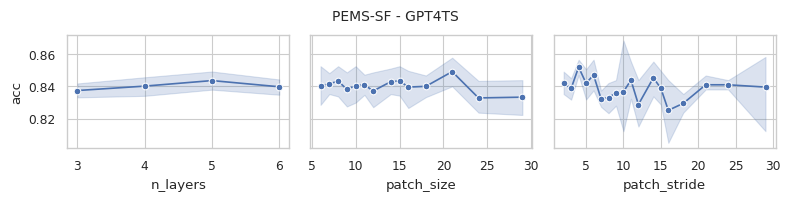

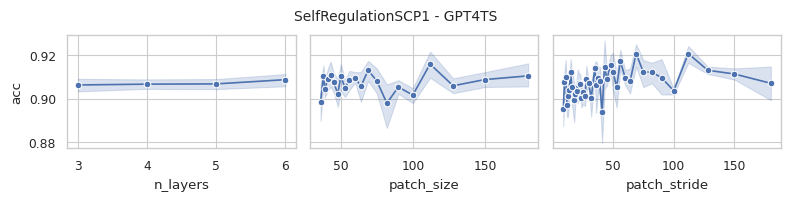

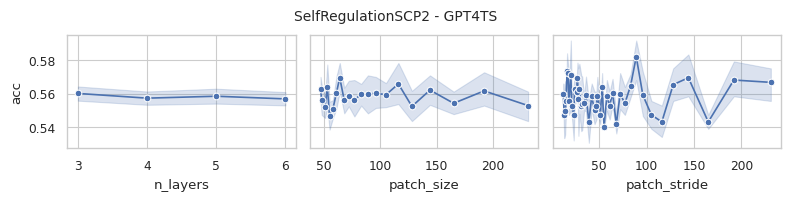

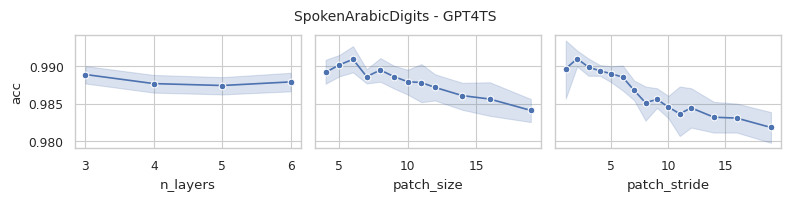

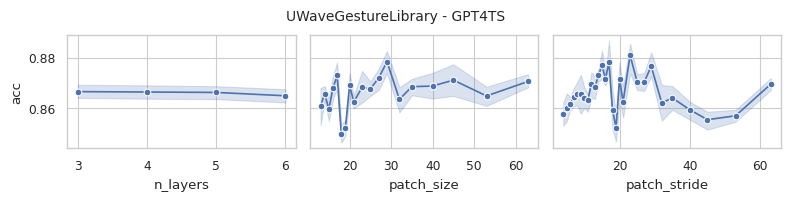

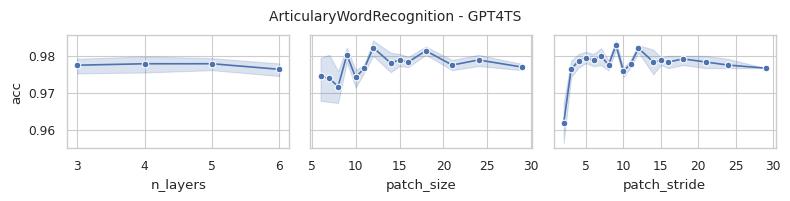

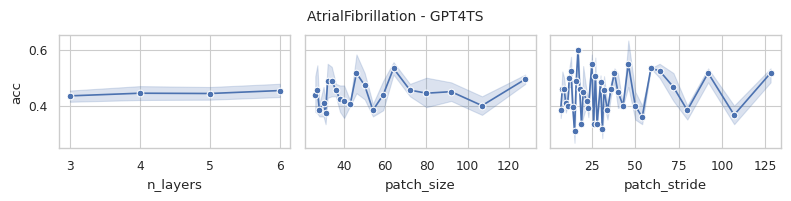

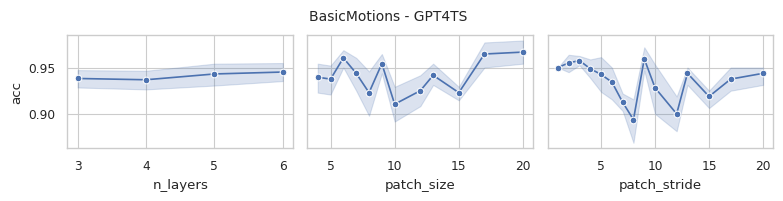

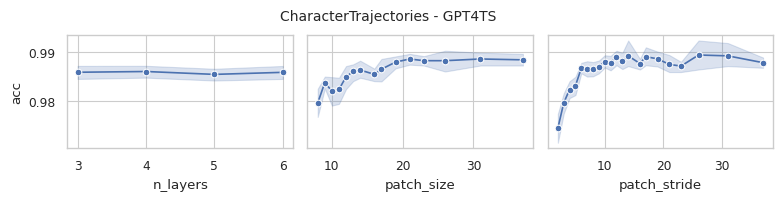

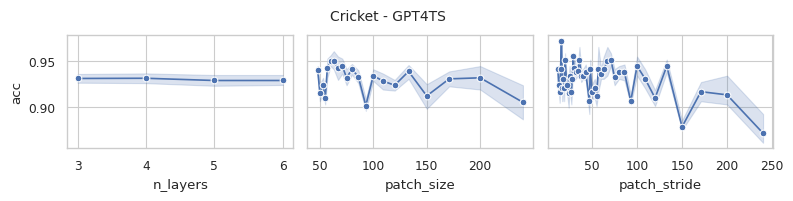

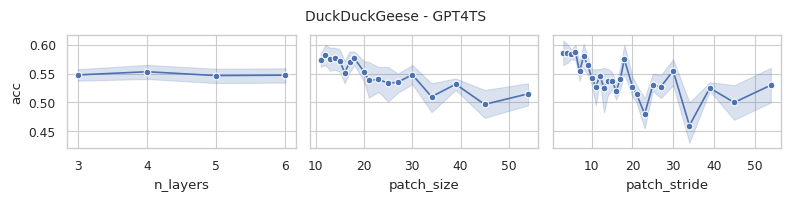

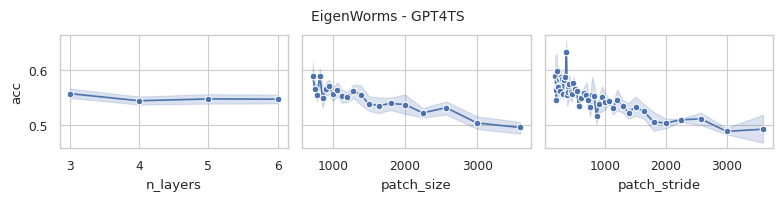

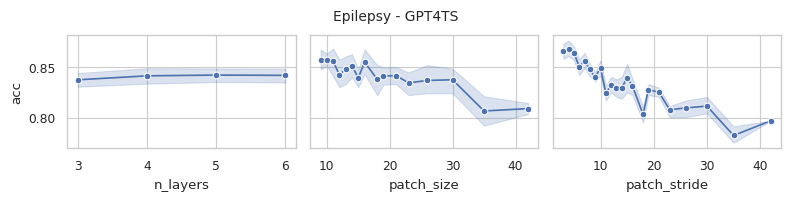

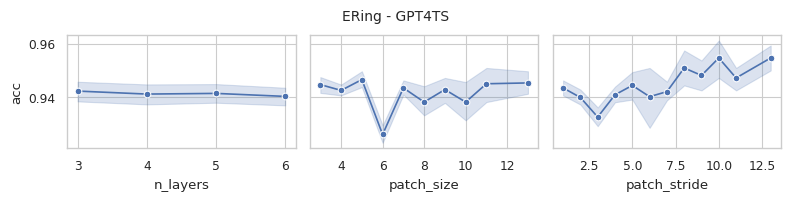

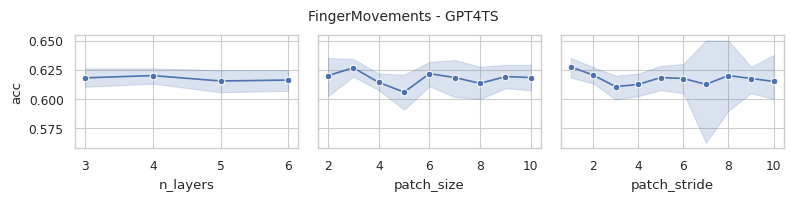

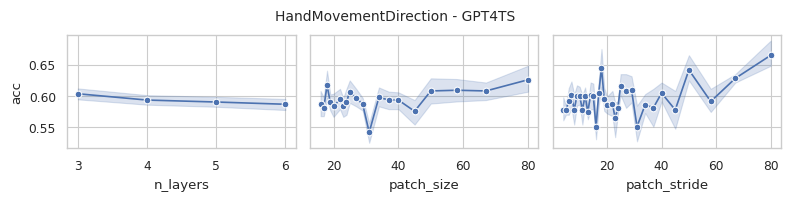

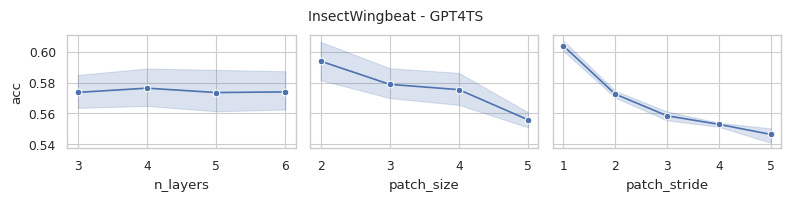

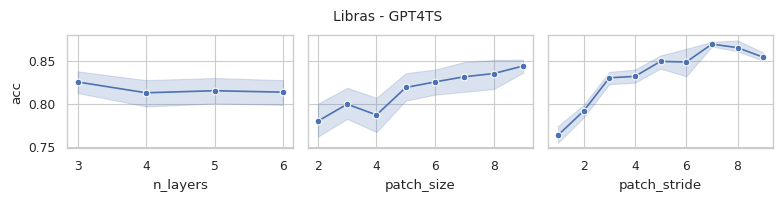

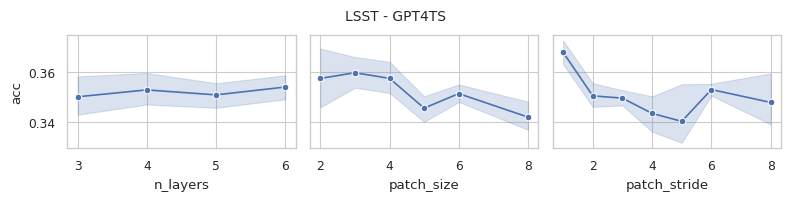

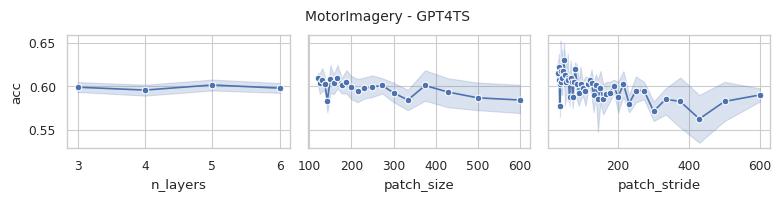

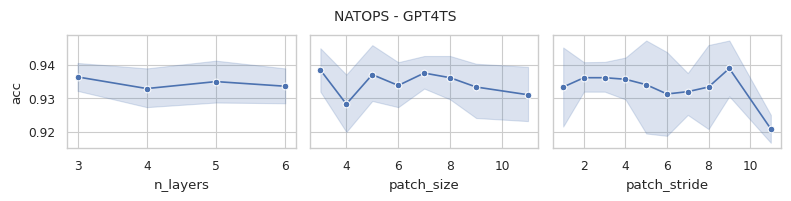

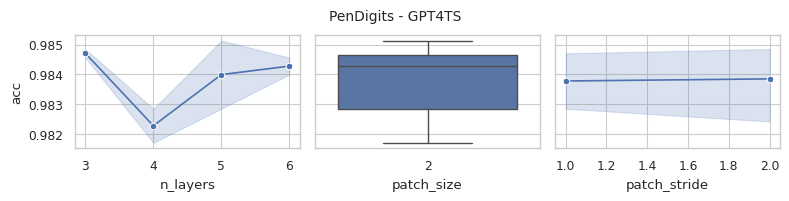

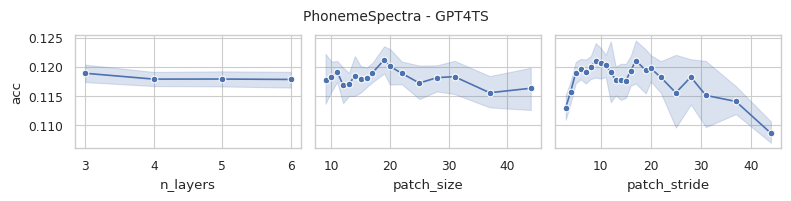

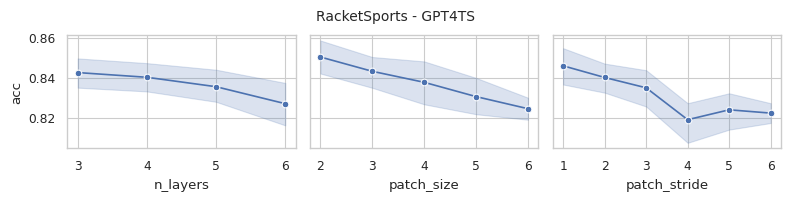

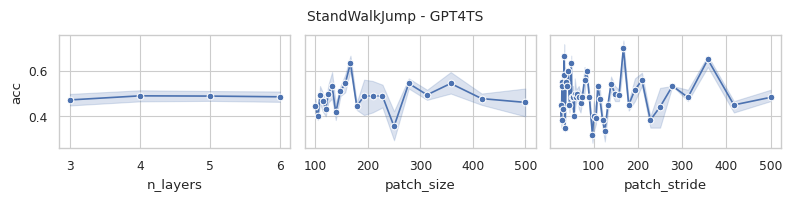

In [4]:
model = 'GPT4TS'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('el', ''))
            data_meta[10] = int(data_meta[10].replace('dm', ''))
            data_meta[11] = int(data_meta[11].replace('df', ''))
            data_meta[12] = int(data_meta[12].replace('ps', ''))
            data_meta[13] = int(data_meta[13].replace('str', ''))

            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'task_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'n_layers': data_meta[9],
                'd_model': data_meta[10],
                'd_ff': data_meta[11],
                'patch_size': data_meta[12],
                'patch_stride': data_meta[13],
                # 'exp': data_meta[15],
                # 'desc': data_meta[16],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df.copy()

    cols = ['n_layers', 'patch_size', 'patch_stride']
    num_cols, num_rows = 3, 1
    
    # # Boxplot
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False, style='model', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 2), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

In [5]:
model_configs = {
    "e_layers" : list(range(3, 7)),
    "d_model" : [768],
    "d_ff" : [768],
    "patch_size_ratio" : [f'1/{i}' for i in range(5, 26)],
    "patch_stride_ratio" : [f'1/{i}' for i in [1,2,4]],
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        seq_len = data_info[f'CLS_{data_name}']["seq_len"]
        enc_in = data_info[f'CLS_{data_name}']["enc_in"]
        n_layers = hyperparameter_combination['e_layers']
        d_model = hyperparameter_combination['d_model']
        d_ff = hyperparameter_combination['d_ff']
        patch_ratio = eval(hyperparameter_combination['patch_size_ratio'])
        stride_ratio = eval(hyperparameter_combination['patch_stride_ratio'])

        patch_size = max(2, math.ceil(patch_ratio * seq_len))
        patch_stride = max(1, math.ceil(patch_ratio * seq_len * stride_ratio))
        
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['n_layers'] == n_layers)
                & (tmp['d_model'] == d_model)
                & (tmp['d_ff'] == d_ff)
                & (tmp['patch_size'] == patch_size)
                & (tmp['patch_stride'] == patch_stride)
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'e_layers': 3, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/19', 'patch_stride_ratio': '1/4'}","{'e_layers': 3, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/20', 'patch_stride_ratio': '1/4'}","{'e_layers': 3, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/19', 'patch_stride_ratio': '1/2'}","{'e_layers': 5, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/25', 'patch_stride_ratio': '1/2'}","{'e_layers': 4, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/19', 'patch_stride_ratio': '1/4'}","{'e_layers': 4, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/20', 'patch_stride_ratio': '1/4'}","{'e_layers': 6, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/20', 'patch_stride_ratio': '1/4'}","{'e_layers': 3, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/15', 'patch_stride_ratio': '1/2'}","{'e_layers': 5, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/20', 'patch_stride_ratio': '1/4'}",...,"{'e_layers': 5, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/21', 'patch_stride_ratio': '1/1'}","{'e_layers': 3, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/5', 'patch_stride_ratio': '1/4'}","{'e_layers': 5, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/5', 'patch_stride_ratio': '1/4'}","{'e_layers': 6, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/8', 'patch_stride_ratio': '1/1'}","{'e_layers': 4, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/10', 'patch_stride_ratio': '1/1'}","{'e_layers': 5, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/12', 'patch_stride_ratio': '1/2'}","{'e_layers': 5, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/6', 'patch_stride_ratio': '1/2'}","{'e_layers': 3, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/21', 'patch_stride_ratio': '1/1'}","{'e_layers': 5, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/8', 'patch_stride_ratio': '1/1'}","{'e_layers': 4, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/6', 'patch_stride_ratio': '1/1'}"
EthanolConcentration,0.323194,0.288973,0.285171,0.281369,0.273764,0.26616,0.281369,0.269962,0.292776,0.26616,...,0.277567,0.277567,0.281369,0.304183,0.281369,0.26616,0.273764,0.288973,0.277567,0.281369
FaceDetection,0.686152,0.673666,0.673666,0.674801,0.679342,0.666005,0.666005,0.678207,0.674518,0.685301,...,0.667991,0.673099,0.67168,0.671112,0.665153,0.663451,0.676788,0.67168,0.675936,0.659762
Handwriting,0.341176,0.298824,0.298824,0.324706,0.311765,0.276471,0.276471,0.28,0.316471,0.287059,...,0.337647,0.310588,0.298824,0.298824,0.297647,0.309412,0.304706,0.330588,0.292941,0.304706
Heartbeat,0.790244,0.756098,0.765854,0.760976,0.756098,0.765854,0.741463,0.770732,0.760976,0.756098,...,0.756098,0.765854,0.770732,0.760976,0.760976,0.756098,0.770732,0.760976,0.780488,0.760976
JapaneseVowels,0.981081,0.981081,0.981081,0.981081,0.975676,0.978378,0.978378,0.975676,0.981081,0.975676,...,0.981081,0.97027,0.975676,0.97027,0.978378,0.978378,0.975676,0.975676,0.972973,0.975676
PEMS-SF,0.884393,0.867052,0.867052,0.849711,0.809249,0.843931,0.843931,0.83815,0.83237,0.843931,...,0.82659,0.815029,0.83237,0.83815,0.843931,0.878613,0.797688,0.83237,0.83237,0.83815
SelfRegulationSCP1,0.931741,0.887372,0.911263,0.897611,0.911263,0.887372,0.901024,0.904437,0.90785,0.897611,...,0.911263,0.901024,0.90785,0.921502,0.897611,0.911263,0.904437,0.901024,0.921502,0.914676
SelfRegulationSCP2,0.605556,0.588889,0.55,0.55,0.577778,0.555556,0.561111,0.555556,0.555556,0.555556,...,0.538889,0.55,0.533333,0.555556,0.544444,0.561111,0.55,0.544444,0.566667,0.555556
SpokenArabicDigits,0.995907,0.99045,0.99045,0.991814,0.986812,0.992269,0.992269,0.993633,0.989541,0.993179,...,0.989541,0.989086,0.983629,0.980446,0.983629,0.99045,0.983629,0.99136,0.983174,0.984993
UWaveGestureLibrary,0.890625,0.8625,0.865625,0.871875,0.865625,0.871875,0.85625,0.8625,0.865625,0.88125,...,0.86875,0.871875,0.878125,0.853125,0.846875,0.88125,0.86875,0.86875,0.859375,0.85625


In [7]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'e_layers': 3, 'd_model': 768, 'd_ff': 768, 'patch_size_ratio': '1/19', 'patch_stride_ratio': '1/4'}"
EthanolConcentration,32.31939163498099,28.89733840304182
FaceDetection,68.61520998864926,67.36662883087401
Handwriting,34.11764705882353,29.88235294117647
Heartbeat,79.02439024390245,75.60975609756098
JapaneseVowels,98.1081081081081,98.1081081081081
PEMS-SF,88.4393063583815,86.70520231213872
SelfRegulationSCP1,93.17406143344709,88.73720136518772
SelfRegulationSCP2,60.55555555555555,58.88888888888889
SpokenArabicDigits,99.59072305593452,99.04502046384719
UWaveGestureLibrary,89.0625,86.25
